<a href="https://colab.research.google.com/github/ErnaZekovic/SQL_and_Excel_Analysis/blob/main/Quantum_Defect_Detection_Accuracy.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd

# Simulate 400 Quantum State measurements (Qubits)
np.random.seed(99)
theta = np.random.uniform(0, np.pi, 400) # Polar angle in spherical coordinates
phi = np.random.uniform(0, 2 * np.pi, 400) # Azimuthal angle

# Physics: Transform spherical quantum coordinates to 3D Cartesian coordinates (Bloch Sphere)
x_bloch = np.sin(theta) * np.cos(phi)
y_bloch = np.sin(theta) * np.sin(phi)
z_bloch = np.cos(theta)

# Quantum Noise (Decoherence defect): High distortion in Z-axis indicates a quantum defect
quantum_noise = z_bloch + np.random.normal(0, 0.1, 400)
defect_label = np.where(np.abs(quantum_noise) > 0.7, 1, 0) # 1 = Defective Qubit, 0 = Healthy Qubit

# Pack into a professional Quantum Dataset
quantum_dataset = pd.DataFrame({
    'Bloch_X': x_bloch,
    'Bloch_Y': y_bloch,
    'Bloch_Z': z_bloch,
    'Quantum_Defect': defect_label
})

print("Quantum Computing Dataset successfully generated!")
print(quantum_dataset.head())

Quantum Computing Dataset successfully generated!
    Bloch_X   Bloch_Y   Bloch_Z  Quantum_Defect
0  0.856459 -0.032516 -0.515190               0
1 -0.992981  0.112193  0.037444               0
2  0.145583 -0.500425 -0.853452               1
3  0.048103 -0.086105  0.995124               1
4 -0.563618 -0.063107 -0.823622               1


Quantum Defect Detection Accuracy: 92.5%



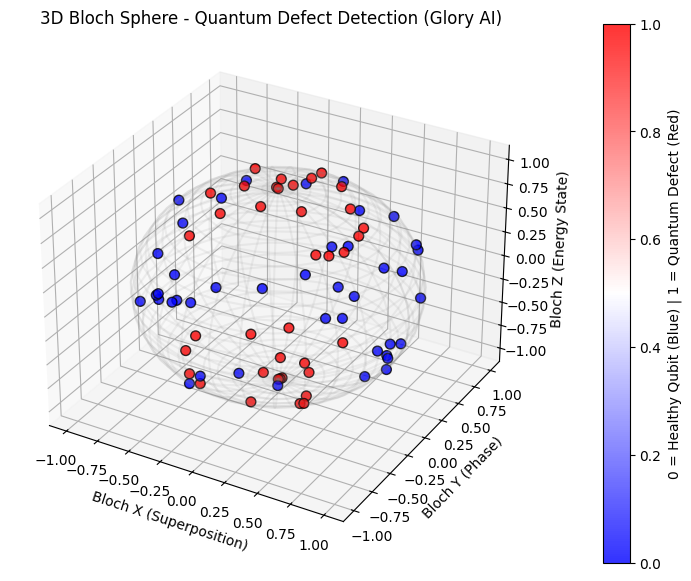

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# 1. Train the Quantum SVM Model
X_quantum = quantum_dataset[['Bloch_X', 'Bloch_Y', 'Bloch_Z']]
y_quantum = quantum_dataset['Quantum_Defect']
X_train, X_test, y_train, y_test = train_test_split(X_quantum, y_quantum, test_size=0.2, random_state=42)

quantum_svc = SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42)
quantum_svc.fit(X_train, y_train)
quantum_predictions = quantum_svc.predict(X_test)

quantum_accuracy = accuracy_score(y_test, quantum_predictions)
print(f"Quantum Defect Detection Accuracy: {quantum_accuracy * 100:.1f}%\n")

# 2. Draw the 3D Bloch Sphere Graph
fig = plt.figure(figsize=(9, 7))
ax = fig.add_subplot(111, projection='3d')
scatter = ax.scatter(X_test['Bloch_X'], X_test['Bloch_Y'], X_test['Bloch_Z'],
                     c=quantum_predictions, cmap='bwr', s=50, edgecolors='k', alpha=0.8)

u = np.linspace(0, 2 * np.pi, 30)
v = np.linspace(0, np.pi, 30)
x_sphere = np.outer(np.cos(u), np.sin(v))
y_sphere = np.outer(np.sin(u), np.sin(v))
z_sphere = np.outer(np.ones(np.size(u)), np.cos(v))
ax.plot_wireframe(x_sphere, y_sphere, z_sphere, color='gray', alpha=0.1)

ax.set_xlabel('Bloch X (Superposition)')
ax.set_ylabel('Bloch Y (Phase)')
ax.set_zlabel('Bloch Z (Energy State)')
ax.set_title('3D Bloch Sphere - Quantum Defect Detection (Glory AI)')
cbar = plt.colorbar(scatter, ax=ax, pad=0.1)
cbar.set_label('0 = Healthy Qubit (Blue) | 1 = Quantum Defect (Red)')
plt.show()